# Hierarchical Clustering - Age, Annual Income and Spending Score

This notebook applies **Hierarchical Clustering** as an **unsupervised learning** method using **Age**, **Annual Income**, and **Spending Score**.

## Step 1: Import Libraries & Load Data
This step imports the required libraries and loads the dataset for clustering analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
import pickle

sns.set(style='whitegrid')

df = pd.read_csv('data/Shopping_Mall_Customer_Segmentation_Data_.csv')
df_clean = df.dropna().drop_duplicates()

print('Dataset shape:', df.shape)
print('Cleaned dataset shape:', df_clean.shape)
display(df_clean.head())

Dataset shape: (15079, 5)
Cleaned dataset shape: (15079, 5)


,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


## Step 2: Data Preparation for Unsupervised Learning
This step selects the features required for hierarchical clustering and standardizes them so that all variables contribute fairly to the clustering process.

In [2]:
# Detect the spending score column name safely
possible_spending_cols = ['Spending Score', 'Spending Score (1-100)', 'SpendingScore']
spending_col = next((col for col in possible_spending_cols if col in df_clean.columns), None)

if spending_col is None:
    raise KeyError("Spending Score column not found. Please check the dataset column name.")

possible_income_cols = ['Annual Income', 'Annual Income (k$)', 'AnnualIncome']
income_col = next((col for col in possible_income_cols if col in df_clean.columns), None)

if income_col is None:
    raise KeyError("Annual Income column not found. Please check the dataset column name.")

features = ['Age', income_col, spending_col]
X = df_clean[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Selected features:', features)
print('Scaled shape:', X_scaled.shape)
display(X.head())

Selected features: ['Age', 'Annual Income', 'Spending Score']
Scaled shape: (15079, 3)


,Age,Annual Income,Spending Score
0,30,151479,89
1,58,185088,95
2,62,70912,76
3,23,55460,57
4,24,153752,76


## Step 3: Train Final Model
In this step, the final Hierarchical Clustering model is trained using Agglomerative Clustering with 5 clusters.

In [3]:
hc_model = AgglomerativeClustering(n_clusters=5, linkage='ward')
cluster_labels = hc_model.fit_predict(X_scaled)

# Get actual number of clusters from model output
n_clusters = len(set(cluster_labels))

df_result = df_clean.copy()
df_result['Cluster'] = cluster_labels

print('Unique clusters:', sorted(df_result['Cluster'].unique()))
print('Number of clusters:', n_clusters)
display(df_result.head())

Unique clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Number of clusters: 5


,Customer ID,Age,Gender,Annual Income,Spending Score,Cluster
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89,0
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95,0
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76,0
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57,3
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76,0


## Step 4: Evaluate the Model
The model is evaluated using the **Silhouette Score** and **Davies-Bouldin Index**, which are suitable for unsupervised learning because they measure cluster separation and compactness.

Since this is an **unsupervised learning** task, no target label is used for training.

In [4]:
# Metrics for selected final model
sil_score = silhouette_score(X_scaled, cluster_labels)
db_score = davies_bouldin_score(X_scaled, cluster_labels)

print('=' * 72)
print('           HIERARCHICAL CLUSTERING EVALUATION METRICS')
print('=' * 72)
print(f'  Algorithm                 : Hierarchical Clustering')
print(f'  Linkage Method            : Ward')
print(f'  Input Feature Space       : X_scaled (Age, Income, Spending)')
print(f'  Number of Clusters        : {n_clusters}')
print(f'  Silhouette Score          : {sil_score:.4f}  (higher = better)')
print(f'  Davies-Bouldin Index      : {db_score:.4f}  (lower = better)')
print(f'  Noise Points              : 0')
print('=' * 72)

decision_df = pd.DataFrame([
    {
        'Pipeline': 'Final: Hierarchical Clustering on X_scaled',
        'K': n_clusters,
        'Silhouette': round(sil_score, 4),
        'Davies-Bouldin': round(db_score, 4),
        'Noise': 0
    }
])

print('\n=== Final decision support ===')
print(decision_df.to_string(index=False))

print('\n📌 User-facing explanation:')
print('   1. Hierarchical Clustering groups customers based on similarity.')
print('   2. Ward linkage is used to minimize within-cluster variance.')
print('   3. Silhouette Score evaluates how well-separated the clusters are.')
print('   4. Davies-Bouldin Index measures cluster compactness and separation.')
print('   5. Hierarchical Clustering does not produce noise points; all data points are assigned to clusters.')

scores = {
    'algorithm': 'HierarchicalClustering',
    'linkage': 'ward',
    'n_clusters': int(n_clusters),
    'silhouette': round(float(sil_score), 4),
    'davies_bouldin': round(float(db_score), 4),
    'noise': 0
}

pickle.dump(scores, open('hierarchical_scores.pkl', 'wb'))
pickle.dump(cluster_labels, open('hierarchical_labels.pkl', 'wb'))

print('\n✅ Scores saved.')

           HIERARCHICAL CLUSTERING EVALUATION METRICS
  Algorithm                 : Hierarchical Clustering
  Linkage Method            : Ward
  Input Feature Space       : X_scaled (Age, Income, Spending)
  Number of Clusters        : 5
  Silhouette Score          : 0.1930  (higher = better)
  Davies-Bouldin Index      : 1.1875  (lower = better)
  Noise Points              : 0

=== Final decision support ===
                                  Pipeline  K  Silhouette  Davies-Bouldin  Noise
Final: Hierarchical Clustering on X_scaled  5       0.193          1.1875      0

📌 User-facing explanation:
   1. Hierarchical Clustering groups customers based on similarity.
   2. Ward linkage is used to minimize within-cluster variance.
   3. Silhouette Score evaluates how well-separated the clusters are.
   4. Davies-Bouldin Index measures cluster compactness and separation.
   5. Hierarchical Clustering does not produce noise points; all data points are assigned to clusters.

✅ Scores saved.


## Cluster Visualisation
This section visualizes the hierarchical clustering results using a 3D scatter plot and a dendrogram.

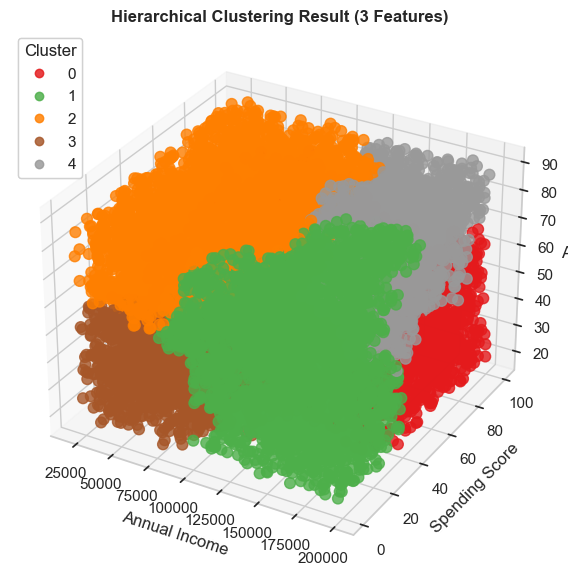

In [5]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_result[income_col],
    df_result[spending_col],
    df_result['Age'],
    c=df_result['Cluster'],
    cmap='Set1',
    s=60,
    alpha=0.8
)

ax.set_title('Hierarchical Clustering Result (3 Features)', fontweight='bold')
ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
legend1 = ax.legend(*scatter.legend_elements(), title='Cluster', loc='upper left')
ax.add_artist(legend1)
plt.show()

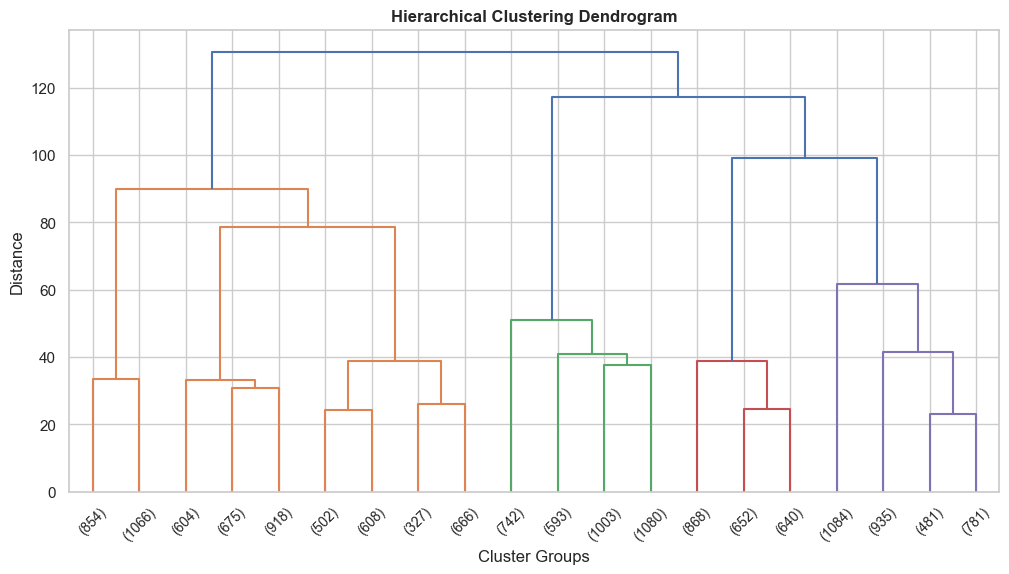

In [6]:
plt.figure(figsize=(12, 6))
linked = linkage(X_scaled, method='ward')
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram', fontweight='bold')
plt.xlabel('Cluster Groups')
plt.ylabel('Distance')
plt.show()

## Cluster Profile Analysis
This section summarizes the average values of the selected features in each cluster to support interpretation of customer segments.

In [7]:
cluster_profile = df_result.groupby('Cluster')[['Age', income_col, spending_col]].mean().round(2)
cluster_profile['Count'] = df_result.groupby('Cluster').size()

display(cluster_profile)

,Age,Annual Income,Spending Score,Count
Cluster,,,,
0,41.14,112601.19,76.59,4300
1,54.88,146212.61,20.40,3281
2,74.78,68394.90,47.97,3418
3,31.61,66317.01,34.04,2160
4,70.99,163482.14,67.25,1920


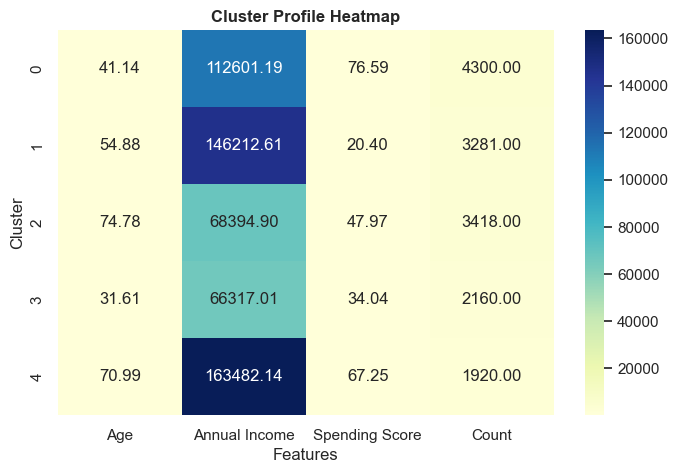

In [8]:
plt.figure(figsize=(8, 5))
sns.heatmap(cluster_profile, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Cluster Profile Heatmap', fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.show()

## Save Model & Predict New Customer
Agglomerative Clustering does not support direct prediction for new data like KMeans. Therefore, this section saves the preprocessing object and demonstrates how a new customer can be transformed for analysis.

In [9]:
joblib.dump(scaler, 'data/hierarchical_scaler.pkl')

print('Scaler saved successfully.')

Scaler saved successfully.


In [10]:
new_customer = pd.DataFrame([{
    'Age': X['Age'].mean(),
    income_col: X[income_col].mean(),
    spending_col: X[spending_col].mean()
}])

new_customer_scaled = scaler.transform(new_customer)

print('New Customer:')
display(new_customer)

print('Scaled New Customer:')
print(new_customer_scaled)

print('Note: AgglomerativeClustering does not provide a built-in predict() function for unseen customers.')

New Customer:


,Age,Annual Income,Spending Score
0,54.191591,109742.880562,50.591617


Scaled New Customer:
[[0. 0. 0.]]
Note: AgglomerativeClustering does not provide a built-in predict() function for unseen customers.
